<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 1. Predict failure risk from sensor data

In this notebook, I build a model to flag risky machine.

The goal is to compare a few models, set a cutoff on validation data, and see which one gives the best final alert list on the test set.

The key point is that the first ranking table is only a starting point. Models can look close in cross validation, then separate once the cutoff is set and the real counts of missed failures and false alarms are visible.

So the final choice is not just about which model scores highest first. It is about which model fits the operating goal best.

</div>

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 2. Imports and settings

This section loads the libraries used in the rest of the notebook and sets the main run settings.

The constants at the bottom control the workflow:

- `TARGET = "fail"` tells the notebook which column to predict
- `RANDOM_STATE = 42` keeps the data split reproducible
- `TEST_SIZE = 0.20` keeps 20% of the rows for the final test set
- `CV_FOLDS = 5` uses five fold cross validation when screening models
- `VALIDATION_SIZE = 0.25` splits the remaining training data again so threshold choices are made on validation, not on test

So this block does not just import code. It fixes the setup the rest of the notebook will follow.

</div>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

TARGET = "fail"
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
VALIDATION_SIZE = 0.25

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">
    
# 3. Load data

This section reads the labeled dataset into a dataframe.

The **predictor columns** are `footfall`, `tempMode`, `AQ`, `USS`, `CS`, `VOC`, `RP`, `IP`, and `Temperature`.


The target is `fail`.

The code below loads the file, checks that `fail` is present, and shows the first few rows so I can confirm the table loaded as expected before doing any cleaning or modeling.

</div>

In [2]:
def load_data(path: str, target: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    if df.empty:
        raise ValueError("Loaded dataframe is empty.")

    if target not in df.columns:
        raise ValueError(f"Missing target column: {target}")

    return df


DATA_PATH = "/kaggle/input/datasets/umerrtx/machine-failure-prediction-using-sensor-data/data.csv"
df = load_data(DATA_PATH, TARGET)

display(df.head())

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 4. Remove duplicates and do a quick data check

I remove exact duplicate rows before modeling, then check the cleaned table for missing values, class balance in `fail`, and feature scale.

Findings:
- one exact duplicate pattern in the raw data, so I remove it
- no missing values in the cleaned table
- `fail` is split about `58.3%` for `0` and `41.7%` for `1`

Because the target is not fully balanced, accuracy alone is not enough, so I also use `ROC AUC`, `average precision`, and `F1`.

Some features are on very different numeric scales, especially `footfall`. That mainly affects linear models, so later I scale them for Logistic Regression so larger values do not dominate the fit more than the actual pattern.

</div>

In [3]:
duplicate_rows = df[df.duplicated(keep=False)]

print(f"Original shape: {df.shape}")

if duplicate_rows.empty:
    print("Duplicate rows found: 0")
else:
    print(f"Duplicate rows found: {len(duplicate_rows)}")
    display(duplicate_rows.reset_index())

df = df.drop_duplicates().reset_index(drop=True)

target_counts = df[TARGET].value_counts().sort_index()
target_props = df[TARGET].value_counts(normalize=True).sort_index()

print(f"\nCleaned shape: {df.shape}")
print(f"Missing values: {int(df.isnull().sum().sum())}")

print("\nTarget distribution")
for label, count in target_counts.items():
    print(f"{label}: {count:,} ({target_props[label]:.1%})")

summary = (
    df.drop(columns=[TARGET])
      .describe()
      .T[["min", "50%", "max"]]
      .rename(columns={"50%": "median"})
)

display(summary)

Original shape: (944, 10)
Duplicate rows found: 2


,index,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,730,31,5,3,3,6,1,48,6,21,0
1,766,31,5,3,3,6,1,48,6,21,0



Cleaned shape: (943, 10)
Missing values: 0

Target distribution
0: 550 (58.3%)
1: 393 (41.7%)


,min,median,max
footfall,0.0,22.0,7300.0
tempMode,0.0,3.0,7.0
AQ,1.0,4.0,7.0
USS,1.0,3.0,7.0
CS,1.0,6.0,7.0
VOC,0.0,2.0,6.0
RP,19.0,44.0,91.0
IP,1.0,4.0,7.0
Temperature,1.0,17.0,24.0


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 5. Separate predictors and target

Here, I split the cleaned table into inputs and labels.

- `X` holds the predictor columns
- `y` holds the target column, `fail`

This is a small step, but it sets up everything that follows. The train, validation, and test split is done from `X` and `y`, and every model later in the notebook is fit on that same separation.

</div>

In [4]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 6. Build train, validation, and test sets

This section gives each split a separate job.

The code first holds out the test set. Then it splits the remaining rows again to create a validation set.

That leaves three parts:

- training set for fitting and comparing models
- validation set for choosing thresholds
- test set for the final check only

This split matters because the notebook is not only comparing models. It is also choosing a decision threshold later. That threshold needs to be chosen on validation data, not on the final test set.

The table below shows how many rows end up in each split and whether the failure rate stays similar across them. That is a quick check that the split is reasonable before model training starts.

</div>

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

split_summary = pd.DataFrame({
    "set": ["full data", "train", "validation", "test"],
    "rows": [len(y), len(y_train), len(y_val), len(y_test)],
    "failure rate": [y.mean(), y_train.mean(), y_val.mean(), y_test.mean()]
})

split_summary["failure rate"] = split_summary["failure rate"].map(lambda v: f"{v:.1%}")
display(split_summary)

,set,rows,failure rate
0,full data,943,41.7%
1,train,565,41.6%
2,validation,189,41.8%
3,test,189,41.8%


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 7. Train a few models, then carry the strongest ones forward

I start by comparing a small set of models on the training split with cross validation.

The table below is only the first screen. It helps me decide which models are strong enough to keep testing. I do not treat it as the final answer, because models that look close here can still behave differently later once I set thresholds and count missed failures and false alarms.

In this run, three models are worth carrying forward:

- SVM RBF
- Extra Trees
- Random Forest

So from here on, the goal is simple: keep these three models, fit them on the training split, and compare how they behave on validation and test data under the same threshold rule.

</div>

In [6]:
def build_pipeline(model_name):
    if model_name == "Logistic Regression":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
        ])

    if model_name == "Random Forest":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=3,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    if model_name == "Extra Trees":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    if model_name == "HistGradientBoosting":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                max_depth=4,
                learning_rate=0.05,
                max_iter=250,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "SVM RBF":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                probability=True,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "XGBoost":
        if not HAS_XGBOOST:
            raise ValueError("XGBoost is not installed in this runtime")
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                verbosity=0
            ))
        ])

    raise ValueError(f"Unknown model: {model_name}")


candidate_models = [
    "Logistic Regression",
    "Random Forest",
    "Extra Trees",
    "HistGradientBoosting",
    "SVM RBF",
]

if HAS_XGBOOST:
    candidate_models.append("XGBoost")

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
benchmark_rows = []

for model_name in candidate_models:
    candidate_pipeline = build_pipeline(model_name)

    scores = cross_validate(
        candidate_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "roc_auc", "average_precision", "f1"],
        n_jobs=-1,
        error_score="raise"
    )

    benchmark_rows.append({
        "model": model_name,
        "accuracy": scores["test_accuracy"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "avg_precision": scores["test_average_precision"].mean(),
        "f1": scores["test_f1"].mean()
    })

benchmark_table = (
    pd.DataFrame(benchmark_rows)
    .sort_values(["avg_precision", "roc_auc", "f1"], ascending=False)
    .reset_index(drop=True)
    .round(3)
)

display(benchmark_table)

models_to_carry = ["SVM RBF", "Extra Trees", "Random Forest"]
model_pipelines = {}

for model_name in models_to_carry:
    pipeline = build_pipeline(model_name)
    pipeline.fit(X_train, y_train)
    model_pipelines[model_name] = pipeline

top_models = models_to_carry

print("Models carried forward:")
for model_name in top_models:
    print(f"- {model_name}")

,model,accuracy,roc_auc,avg_precision,f1
0,SVM RBF,0.912,0.972,0.964,0.892
1,Extra Trees,0.915,0.972,0.963,0.900
2,Random Forest,0.920,0.969,0.962,0.906
3,Logistic Regression,0.915,0.973,0.961,0.898
4,HistGradientBoosting,0.901,0.960,0.948,0.880
5,XGBoost,0.904,0.962,0.947,0.886


Models carried forward:
- SVM RBF
- Extra Trees
- Random Forest


<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 8. Check validation performance for the three finalists

This is the first comparison on unseen rows. At this stage, all three models are still using their default cutoff.

The table and confusion matrices show a clear pattern.

SVM RBF is the most selective of the three. It raises the fewest false alarms, 14, but it also misses the most failures, 12.

Extra Trees and Random Forest both catch more true failures than SVM RBF. Extra Trees catches 70 and misses 9. Random Forest catches 71 and misses 8. That is why both move ahead of SVM RBF on recall and F1.

Between those two, Random Forest finds 1 more true failure than Extra Trees, but it also adds 1 more false alarm. That keeps them very close, with Random Forest slightly ahead on recall and F1, and Extra Trees slightly ahead on precision.

So after the validation check:

- SVM RBF looks a bit too cautious
- Extra Trees looks balanced
- Random Forest looks slightly more recall focused

That is why all three are still worth carrying into the threshold step.

</div>

,model,accuracy,roc_auc,avg_precision,precision,recall,f1,false_alarms,missed_failures,flagged_rows
0,SVM RBF,0.862,0.947,0.948,0.827,0.848,0.838,14,12,81
1,Extra Trees,0.873,0.946,0.947,0.824,0.886,0.854,15,9,85
2,Random Forest,0.873,0.940,0.940,0.816,0.899,0.855,16,8,87


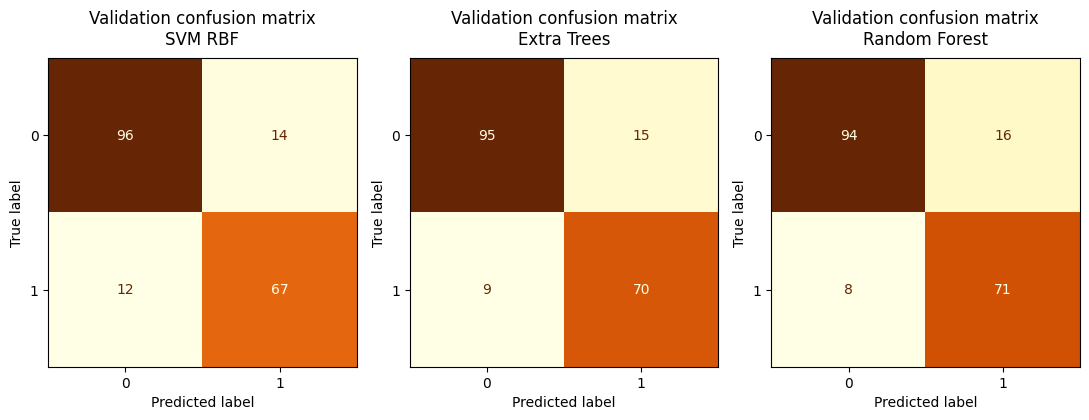

In [7]:
validation_rows = []
validation_outputs = {}

for model_name in top_models:
    pipeline = model_pipelines[model_name]

    y_val_pred_default = pipeline.predict(X_val)
    y_val_proba = pipeline.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred_default).ravel()

    validation_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_val_pred_default),
        "roc_auc": roc_auc_score(y_val, y_val_proba),
        "avg_precision": average_precision_score(y_val, y_val_proba),
        "precision": precision_score(y_val, y_val_pred_default, zero_division=0),
        "recall": recall_score(y_val, y_val_pred_default, zero_division=0),
        "f1": f1_score(y_val, y_val_pred_default, zero_division=0),
        "false_alarms": int(fp),
        "missed_failures": int(fn),
        "flagged_rows": int(tp + fp),
    })

    validation_outputs[model_name] = {
        "y_pred": y_val_pred_default,
        "y_proba": y_val_proba
    }

validation_metrics = pd.DataFrame(validation_rows).round(3)
display(validation_metrics)

fig, axes = plt.subplots(1, len(top_models), figsize=(11, 4.4))

if len(top_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_models):
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        validation_outputs[model_name]["y_pred"],
        cmap="YlOrBr",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"Validation confusion matrix\n{model_name}", pad=10)

plt.tight_layout()
plt.show()

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 9. Check which variables matter most for each model

This section checks whether the three models are picking up the same failure signal or learning different patterns.

They are mostly picking up the same one.

Across all three models:

- VOC is the strongest feature by a wide margin
- USS is second
- AQ and CS still help
- the remaining variables add little

The importance values are also very close across models. VOC stays around 0.21 in all three. USS stays around 0.03 to 0.04. AQ and CS stay well below that, and the rest are near zero.

That matters because the final difference between these models is not coming from a different view of the data. They are reading almost the same signal. The real difference comes from how each model turns that signal into final alerts.

</div>

,feature,SVM RBF | importance,SVM RBF | tier,Extra Trees | importance,Extra Trees | tier,Random Forest | importance,Random Forest | tier
0,VOC,0.2065,high,0.2152,high,0.2140,high
1,USS,0.0448,medium,0.0406,medium,0.0341,medium
2,AQ,0.0260,medium,0.0299,medium,0.0292,medium
3,CS,0.0209,medium,0.0177,medium,0.0198,medium
4,footfall,0.0083,low,0.0021,low,0.0004,low
5,RP,0.0018,low,-0.0021,low,-0.0009,low
6,IP,0.0010,low,-0.0001,low,0.0002,low
7,Temperature,0.0002,low,-0.0025,low,-0.0011,low
8,tempMode,-0.0014,low,-0.0005,low,-0.0002,low


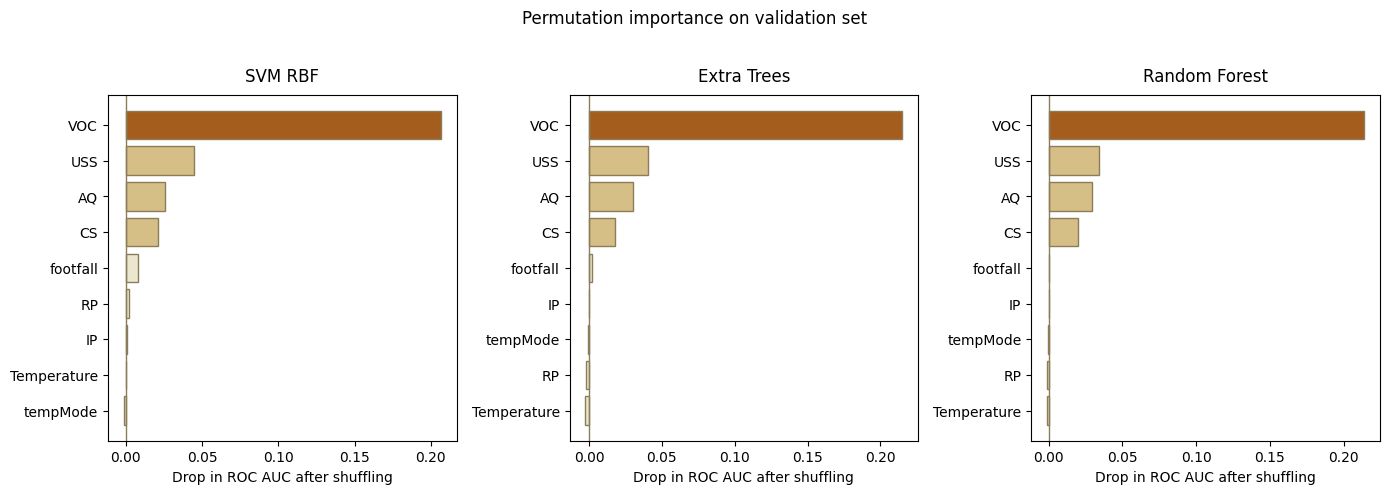

In [8]:
importance_results = {}

for model_name in top_models:
    pipeline = model_pipelines[model_name]

    perm = permutation_importance(
        pipeline,
        X_val,
        y_val,
        n_repeats=20,
        random_state=RANDOM_STATE,
        scoring="roc_auc",
        n_jobs=-1,
    )

    importance_table = (
        pd.DataFrame({
            "feature": X_val.columns,
            "importance": perm.importances_mean,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
        .round(4)
    )

    def assign_importance_tier(value):
        if value >= 0.05:
            return "high"
        if value >= 0.01:
            return "medium"
        return "low"

    importance_table["tier"] = importance_table["importance"].apply(assign_importance_tier)

    importance_results[model_name] = importance_table

display(
    pd.concat(
        [importance_results[name].set_index("feature")[["importance", "tier"]].add_prefix(f"{name} | ") for name in top_models],
        axis=1
    ).reset_index()
)

tier_colors = {
    "low": "#ece6cf",
    "medium": "#d6bf86",
    "high": "#a55d1d",
}

fig, axes = plt.subplots(1, len(top_models), figsize=(14, 4.8), sharex=False)

if len(top_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_models):
    importance_table = importance_results[model_name]
    bar_colors = importance_table["tier"].map(tier_colors)

    ax.barh(
        importance_table["feature"],
        importance_table["importance"],
        color=bar_colors,
        edgecolor="#8b7d5a",
        linewidth=1.0,
    )
    ax.axvline(0, color="#8b7d5a", linewidth=1)
    ax.set_title(model_name, pad=10)
    ax.set_xlabel("Drop in ROC AUC after shuffling")
    ax.set_ylabel("")
    ax.invert_yaxis()

plt.suptitle("Permutation importance on validation set", y=1.02)
plt.tight_layout()
plt.show()

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 10. Choose a threshold for each model, then compare final test results

So far, the models have been checked with their default cutoff. Here, I set a cutoff for actual use.

The threshold is chosen on the validation split with three rules:

- review at most 90 rows
- keep recall at or above 0.90 when possible
- count 1 missed failure as 10 false alarms

In code, that is:

- `max_reviews_available = 90`
- `max_alert_rate = max_reviews_available / len(y_val)`
- `min_recall = 0.90`
- `miss_cost = 10`
- `false_alarm_cost = 1`

`max_alert_rate = max_reviews_available / len(y_val)` turns the 90 row review limit into the largest share of validation rows the model can flag.

The selected cutoffs in this run are:

- SVM RBF: 0.256
- Extra Trees: 0.338
- Random Forest: 0.294

After thresholding, the final result is clear:

- Extra Trees and Random Forest catch the same number of failures
- Extra Trees does it with 2 fewer false alarms
- SVM RBF finishes behind both on missed failures and cost

ROC AUC stays very close across all three models, so the final choice comes from the alert list after thresholding, not from ranking score alone.

</div>

In [9]:
daily_review_capacity = 90

false_alarm_cost = 1
deferred_failure_cost = 10

def build_ranked_queue(y_true, y_score, daily_capacity):
    queue = pd.DataFrame({
        "actual_fail": np.asarray(y_true),
        "risk_score": np.asarray(y_score),
    }).sort_values("risk_score", ascending=False).reset_index(drop=True)

    queue["rank"] = np.arange(1, len(queue) + 1)

    queue["action_plan"] = np.select(
        [
            queue["rank"] <= daily_capacity,
            queue["rank"] <= (2 * daily_capacity),
        ],
        [
            "review today",
            "next review batch",
        ],
        default="monitor later"
    )

    queue["review_today"] = (queue["action_plan"] == "review today").astype(int)
    return queue


ranked_results = []
ranked_queues = {}

for model_name in top_models:
    pipeline = model_pipelines[model_name]

    y_test_proba = pipeline.predict_proba(X_test)[:, 1]
    queue = build_ranked_queue(y_test, y_test_proba, daily_review_capacity)
    ranked_queues[model_name] = queue

    today_queue = queue[queue["action_plan"] == "review today"].copy()
    deferred_queue = queue[queue["action_plan"] != "review today"].copy()

    rows_reviewed_today = int(len(today_queue))
    true_failures_in_today_queue = int(today_queue["actual_fail"].sum())
    false_alarms_in_today_queue = int(rows_reviewed_today - true_failures_in_today_queue)
    true_failures_deferred = int(deferred_queue["actual_fail"].sum())

    precision_today = (
        true_failures_in_today_queue / rows_reviewed_today
        if rows_reviewed_today > 0 else 0.0
    )

    total_failures = int(queue["actual_fail"].sum())
    recall_today = (
        true_failures_in_today_queue / total_failures
        if total_failures > 0 else 0.0
    )

    avg_precision = average_precision_score(y_test, y_test_proba)
    roc_auc = roc_auc_score(y_test, y_test_proba)

    review_cost_today = false_alarms_in_today_queue * false_alarm_cost
    deferral_cost_today = true_failures_deferred * deferred_failure_cost
    total_queue_cost = review_cost_today + deferral_cost_today

    ranked_results.append({
        "model": model_name,
        "roc_auc": roc_auc,
        "avg_precision": avg_precision,
        "rows_reviewed_today": rows_reviewed_today,
        "true_failures_in_today_queue": true_failures_in_today_queue,
        "false_alarms_in_today_queue": false_alarms_in_today_queue,
        "true_failures_deferred": true_failures_deferred,
        "precision_today": precision_today,
        "recall_today": recall_today,
        "review_cost_today": review_cost_today,
        "deferral_cost_today": deferral_cost_today,
        "total_queue_cost": total_queue_cost,
    })

ranked_summary = (
    pd.DataFrame(ranked_results)
    .sort_values(
        ["total_queue_cost", "true_failures_in_today_queue", "false_alarms_in_today_queue", "avg_precision"],
        ascending=[True, False, True, False]
    )
    .reset_index(drop=True)
)

friendly_summary = ranked_summary.rename(columns={
    "model": "Model",
    "roc_auc": "ROC AUC",
    "avg_precision": "Avg Precision",
    "rows_reviewed_today": "Rows Reviewed Today",
    "true_failures_in_today_queue": "True Failures Today",
    "false_alarms_in_today_queue": "False Alarms Today",
    "true_failures_deferred": "True Failures Deferred",
    "precision_today": "Precision Today",
    "recall_today": "Recall Today",
    "review_cost_today": "Review Cost",
    "deferral_cost_today": "Deferral Cost",
    "total_queue_cost": "Total Cost",
}).round({
    "ROC AUC": 3,
    "Avg Precision": 3,
    "Precision Today": 3,
    "Recall Today": 3,
    "Review Cost": 0,
    "Deferral Cost": 0,
    "Total Cost": 0,
})

def style_summary_table(df):
    best_model = df.iloc[0]["Model"]

    max_true_today = df["True Failures Today"].max()
    min_false_today = df["False Alarms Today"].min()
    min_deferred = df["True Failures Deferred"].min()
    min_total_cost = df["Total Cost"].min()

    styles = pd.DataFrame("", index=df.index, columns=df.columns)

    # highlight best row lightly
    best_idx = df.index[df["Model"] == best_model]
    if len(best_idx) > 0:
        styles.loc[best_idx[0], :] = "background-color: #f3ead0;"

    # model label slightly stronger
    styles["Model"] = styles["Model"] + "font-weight: 600;"

    # highlight good outcome columns
    for idx in df.index[df["True Failures Today"] == max_true_today]:
        styles.loc[idx, "True Failures Today"] += "background-color: #a55d1d; color: white; font-weight: 700;"

    for idx in df.index[df["False Alarms Today"] == min_false_today]:
        styles.loc[idx, "False Alarms Today"] += "background-color: #d6bf86; color: #3d3325; font-weight: 700;"

    for idx in df.index[df["True Failures Deferred"] == min_deferred]:
        styles.loc[idx, "True Failures Deferred"] += "background-color: #8b7d5a; color: white; font-weight: 700;"

    for idx in df.index[df["Total Cost"] == min_total_cost]:
        styles.loc[idx, "Total Cost"] += "background-color: #d6bf86; color: #3d3325; font-weight: 700;"

    return styles

styled_summary = (
    friendly_summary.style
    .hide(axis="index")
    .apply(style_summary_table, axis=None)
    .set_caption("How each model performs when the team can review 90 rows today")
)

display(styled_summary)

best_model = ranked_summary.iloc[0]["model"]
best_queue = ranked_queues[best_model].copy()

queue_preview = best_queue[[
    "rank",
    "risk_score",
    "actual_fail",
    "action_plan"
]].head(20).copy()

queue_preview = queue_preview.rename(columns={
    "rank": "Rank",
    "risk_score": "Risk Score",
    "actual_fail": "Actual Fail",
    "action_plan": "Action Plan",
}).round({"Risk Score": 3})

display(queue_preview)

print(f"Best model for today's review queue: {best_model}")

print("\nHow to read the table colors:")
print("- dark orange: highest number of true failures found today")
print("- sand: lowest false alarms today and lowest total cost")
print("- olive brown: fewest true failures deferred")

Model,ROC AUC,Avg Precision,Rows Reviewed Today,True Failures Today,False Alarms Today,True Failures Deferred,Precision Today,Recall Today,Review Cost,Deferral Cost,Total Cost
Random Forest,0.977000,0.964000,90,76,14,3,0.844000,0.962000,14,30,44
Extra Trees,0.975000,0.963000,90,76,14,3,0.844000,0.962000,14,30,44
SVM RBF,0.976000,0.959000,90,75,15,4,0.833000,0.949000,15,40,55


,Rank,Risk Score,Actual Fail,Action Plan
0,1,0.997,1,review today
1,2,0.997,1,review today
2,3,0.997,1,review today
3,4,0.997,1,review today
4,5,0.997,1,review today
5,6,0.997,1,review today
6,7,0.996,1,review today
7,8,0.996,1,review today
8,9,0.994,1,review today
9,10,0.993,1,review today


Best model for today's review queue: Random Forest

How to read the table colors:
- dark orange: highest number of true failures found today
- sand: lowest false alarms today and lowest total cost
- olive brown: fewest true failures deferred


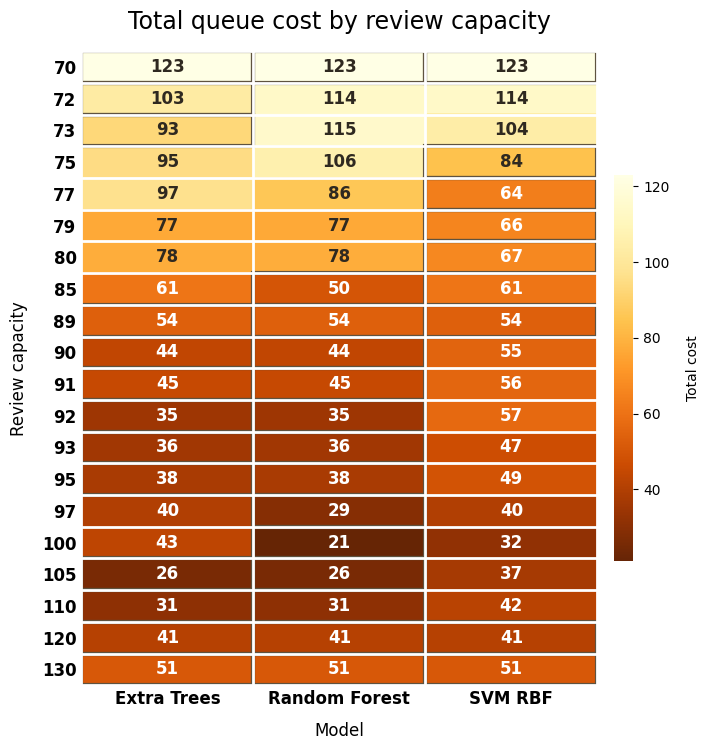

Capacity,Model,True Failures Today,False Alarms Today,True Failures Deferred,Total Cost
70,Extra Trees,67,3,12,123
75,SVM RBF,71,4,8,84
85,Random Forest,75,10,4,50
89,Extra Trees,75,14,4,54
97,Random Forest,78,19,1,29
105,Extra Trees,79,26,0,26


How to read the heatmap:
- darker cells = lower total cost
- outlined cell = winning model at that capacity
- the small table below shows only the capacities where the winner changes


In [10]:
capacity_range = [70, 72, 73, 75, 77, 79, 80, 85, 89, 90, 91, 92, 93, 95,97,100, 105, 110, 120, 130]

false_alarm_cost = 1
deferred_failure_cost = 10

model_order = ["Extra Trees", "Random Forest", "SVM RBF"]

def build_ranked_queue(y_true, y_score, capacity):
    queue = (
        pd.DataFrame({
            "actual_fail": np.asarray(y_true),
            "risk_score": np.asarray(y_score),
        })
        .sort_values("risk_score", ascending=False)
        .reset_index(drop=True)
    )
    queue["rank"] = np.arange(1, len(queue) + 1)
    queue["review_today"] = queue["rank"] <= capacity
    return queue

def evaluate_capacity(queue, capacity):
    today = queue[queue["review_today"]]
    later = queue[~queue["review_today"]]

    rows_reviewed_today = int(len(today))
    true_failures_today = int(today["actual_fail"].sum())
    false_alarms_today = rows_reviewed_today - true_failures_today
    true_failures_deferred = int(later["actual_fail"].sum())

    total_failures = int(queue["actual_fail"].sum())
    precision_today = true_failures_today / rows_reviewed_today if rows_reviewed_today else 0.0
    recall_today = true_failures_today / total_failures if total_failures else 0.0
    total_cost = (
        false_alarms_today * false_alarm_cost
        + true_failures_deferred * deferred_failure_cost
    )

    return {
        "Capacity": capacity,
        "Rows Reviewed Today": rows_reviewed_today,
        "True Failures Today": true_failures_today,
        "False Alarms Today": false_alarms_today,
        "True Failures Deferred": true_failures_deferred,
        "Precision Today": precision_today,
        "Recall Today": recall_today,
        "Total Cost": total_cost,
    }

rows = []

for model_name in model_order:
    y_test_proba = model_pipelines[model_name].predict_proba(X_test)[:, 1]

    for capacity in capacity_range:
        queue = build_ranked_queue(y_test, y_test_proba, capacity)
        metrics = evaluate_capacity(queue, capacity)
        metrics["Model"] = model_name
        rows.append(metrics)

capacity_results = pd.DataFrame(rows)

capacity_results = capacity_results[[
    "Capacity", "Model",
    "Rows Reviewed Today",
    "True Failures Today",
    "False Alarms Today",
    "True Failures Deferred",
    "Precision Today",
    "Recall Today",
    "Total Cost",
]].sort_values(["Capacity", "Model"])

cost_matrix = (
    capacity_results
    .pivot(index="Capacity", columns="Model", values="Total Cost")
    [model_order]
)

winner_rows = (
    capacity_results
    .sort_values(
        ["Capacity", "Total Cost", "True Failures Today", "False Alarms Today", "Precision Today"],
        ascending=[True, True, False, True, False]
    )
    .groupby("Capacity", as_index=False)
    .first()
)

change_points = winner_rows.loc[
    winner_rows["Model"].ne(winner_rows["Model"].shift())
][[
    "Capacity", "Model", "True Failures Today", "False Alarms Today",
    "True Failures Deferred", "Total Cost"
]].reset_index(drop=True)

# ---- main visual: one heatmap only ----
fig, ax = plt.subplots(figsize=(7.2, 7.6))

im = ax.imshow(cost_matrix.values, cmap="YlOrBr_r", aspect="auto")

# axis labels
ax.set_xticks(np.arange(len(cost_matrix.columns)))
ax.set_xticklabels(cost_matrix.columns, fontsize=12, fontweight="bold")
ax.set_yticks(np.arange(len(cost_matrix.index)))
ax.set_yticklabels(cost_matrix.index, fontsize=12, fontweight="bold")
ax.set_xlabel("Model", fontsize=12, labelpad=10)
ax.set_ylabel("Review capacity", fontsize=12, labelpad=10)
ax.set_title("Total queue cost by review capacity", fontsize=17, pad=16)

# annotate cells
vmin = np.nanmin(cost_matrix.values)
vmax = np.nanmax(cost_matrix.values)
mid = (vmin + vmax) / 2

for i in range(cost_matrix.shape[0]):
    row_vals = cost_matrix.iloc[i].values
    row_min = np.min(row_vals)

    for j in range(cost_matrix.shape[1]):
        val = cost_matrix.iloc[i, j]
        txt_color = "white" if val <= mid else "#2f2920"

        ax.text(
            j, i, f"{int(val)}",
            ha="center", va="center",
            fontsize=12, fontweight="bold",
            color=txt_color,
        )

        # outline winner cell for that capacity
        if val == row_min:
            rect = plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                fill=False, edgecolor="#5f5340", linewidth=3
            )
            ax.add_patch(rect)

# clean look
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(np.arange(-0.5, cost_matrix.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, cost_matrix.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(length=0)

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cbar.ax.set_ylabel("Total cost", rotation=90, labelpad=12)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

display(
    change_points.round(0).style.hide(axis="index").set_caption(
        "Winner changes only at these capacities"
    )
)

print("How to read the heatmap:")
print("- darker cells = lower total cost")
print("- outlined cell = winning model at that capacity")
print("- the small table below shows only the capacities where the winner changes")

<div style="background:#f6f1e3; padding:16px 20px; border-radius:10px; border:1px solid #dbcda3;">

# 11. Final takeaway

The first ranking table was useful, but it did not answer the final question. That only became clear after I set thresholds and looked at the final error counts.

In this run, Extra Trees is the model I would use.

Why:

- it catches more real failures
- it misses fewer failures
- it sends fewer false alarms for review

That means it is better both for finding risky rows and for keeping the review list cleaner.

SVM RBF is still worth keeping in the notebook because it stayed close enough to make the comparison meaningful. But if I had to choose one model from this run, I would choose Extra Trees.

The main point is practical: the final choice did not come from the first ranking table. It came later, once the cutoff was set and the actual counts of missed failures and false alarms were visible.

</div>
